#### Dependencies

In [ ]:
%pip install scikit-learn

#### Imports

In [24]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

sns.set_style("whitegrid")

#### Load Cleaned Dataset

In [40]:
DATA_PATH = "..\\data\\cleaned_ai_stocks_task1.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(2109, 53)


,Date,AMD_Close,MSFT_Close,NVDA_Close,^IXIC_Close,AMD_High,MSFT_High,NVDA_High,^IXIC_High,AMD_Low,...,NVDA_Return_Capped,NVDA_Volume_Capped,^IXIC_Return,^IXIC_LogReturn,^IXIC_NormClose,^IXIC_MA20,^IXIC_MA50,^IXIC_Volatility20,^IXIC_Return_Capped,^IXIC_Volume_Capped
0,2018-01-02,10.98,78.699905,4.928265,7006.899902,11.02,79.029539,4.931973,7006.910156,10.34,...,NaN,355616000,NaN,NaN,100.000000,NaN,NaN,NaN,NaN,1929700000
1,2018-01-03,11.55,79.066162,5.252614,7065.529785,12.14,79.212669,5.283022,7069.149902,11.36,...,0.065814,914704000,0.008367,0.008333,100.836745,NaN,NaN,NaN,0.008367,2173130000
2,2018-01-04,12.12,79.762062,5.280303,7077.910156,12.43,80.265671,5.390561,7098.049805,11.97,...,0.005271,583268000,0.001752,0.001751,101.013433,NaN,NaN,NaN,0.001752,2103220000
3,2018-01-05,11.88,80.750946,5.325050,7136.560059,12.22,80.952390,5.362380,7137.040039,11.66,...,0.008474,580124000,0.008286,0.008252,101.850464,NaN,NaN,NaN,0.008286,2024000000
4,2018-01-08,12.28,80.833359,5.488214,7157.390137,12.30,81.108056,5.562378,7161.350098,11.85,...,0.030641,881216000,0.002919,0.002915,102.147743,NaN,NaN,NaN,0.002919,2055010000


#### Convert Date Column

In [41]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print(df[["Date"]].head())

        Date
0 2018-01-02
1 2018-01-03
2 2018-01-04
3 2018-01-05
4 2018-01-08


In [42]:
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month
df["DayOfYear"] = df["Date"].dt.dayofyear

lag_columns = [
    "NVDA_Close",
    "NVDA_Return",
    "NVDA_Volume",
    "MSFT_Return",
    "AMD_Return",
    "^IXIC_Return"
]

for column in lag_columns:
    df[f"{column}_Lag1"] = df[column].shift(1)

df["NVDA_Return_Roll5"] = df["NVDA_Return"].rolling(window=5).mean()
df["NVDA_Volume_Roll5"] = df["NVDA_Volume"].rolling(window=5).mean()

print(df[["Date", "DayOfWeek", "Month", "DayOfYear"]].head())

        Date  DayOfWeek  Month  DayOfYear
0 2018-01-02          1      1          2
1 2018-01-03          2      1          3
2 2018-01-04          3      1          4
3 2018-01-05          4      1          5
4 2018-01-08          0      1          8


#### Create Prediction Target

We predict:

*Will NVDA price go UP tomorrow?*

Target:
- 1 → Price increases
- 0 → Price decreases

In [43]:
# Tomorrow close
df["NVDA_Tomorrow_Close"] = df["NVDA_Close"].shift(-1)

# Binary target
df["Target"] = (
    df["NVDA_Tomorrow_Close"] > df["NVDA_Close"]
).astype(int)

print(df[["NVDA_Close", "NVDA_Tomorrow_Close", "Target"]].head())

   NVDA_Close  NVDA_Tomorrow_Close  Target
0    4.928265             5.252614       1
1    5.252614             5.280303       1
2    5.280303             5.325050       1
3    5.325050             5.488214       1
4    5.488214             5.486730       0


#### Select Features

In [44]:
feature_columns = [
    "NVDA_Close",
    "NVDA_Volume",
    "NVDA_Return",
    "NVDA_MA20",
    "NVDA_MA50",
    "NVDA_Volatility20",
    "DayOfWeek",
    "Month",
    "DayOfYear",
    "NVDA_Close_Lag1",
    "NVDA_Return_Lag1",
    "NVDA_Volume_Lag1",
    "MSFT_Return_Lag1",
    "AMD_Return_Lag1",
    "^IXIC_Return_Lag1",
    "NVDA_Return_Roll5",
    "NVDA_Volume_Roll5",
    "MSFT_Close",
    "AMD_Close",
    "^IXIC_Close",
    "MSFT_Return",
    "AMD_Return",
    "^IXIC_Return"
]

model_df = df[feature_columns + ["Target"]].copy()

print(model_df.head())

   NVDA_Close  NVDA_Volume  NVDA_Return  NVDA_MA20  NVDA_MA50  \
0    4.928265    355616000          NaN        NaN        NaN   
1    5.252614    914704000     0.065814        NaN        NaN   
2    5.280303    583268000     0.005271        NaN        NaN   
3    5.325050    580124000     0.008474        NaN        NaN   
4    5.488214    881216000     0.030641        NaN        NaN   

   NVDA_Volatility20  DayOfWeek  Month  DayOfYear  NVDA_Close_Lag1  ...  \
0                NaN          1      1          2              NaN  ...   
1                NaN          2      1          3         4.928265  ...   
2                NaN          3      1          4         5.252614  ...   
3                NaN          4      1          5         5.280303  ...   
4                NaN          0      1          8         5.325050  ...   

   ^IXIC_Return_Lag1  NVDA_Return_Roll5  NVDA_Volume_Roll5  MSFT_Close  \
0                NaN                NaN                NaN   78.699905   
1         

#### Handle Missing Values

In [45]:
model_df = model_df.dropna().reset_index(drop=True)

print(model_df.shape)
print(model_df.isna().sum().sum())

(2060, 24)
0


#### Feature Matrix & Target

In [46]:
X = model_df[feature_columns]
y = model_df["Target"]

print(X.shape)
print(y.shape)

(2060, 23)
(2060,)


#### Train Test Split

In [47]:
split_index = int(len(model_df) * 0.8)

X = model_df[feature_columns]
y = model_df["Target"]

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True).round(4))
print("Test target distribution:\n", y_test.value_counts(normalize=True).round(4))

Train shape: (1648, 23)
Test shape: (412, 23)
Train target distribution:
 Target
1    0.5388
0    0.4612
Name: proportion, dtype: float64
Test target distribution:
 Target
1    0.5388
0    0.4612
Name: proportion, dtype: float64


#### Standardize Features

In [48]:
tscv = TimeSeriesSplit(n_splits=5)

print("TimeSeriesSplit folds:", tscv.get_n_splits())

TimeSeriesSplit folds: 5


#### Logistic Regression

In [49]:
log_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

log_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

log_search = GridSearchCV(
    estimator=log_pipeline,
    param_grid=log_grid,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1
)

log_search.fit(X_train, y_train)

log_model = log_search.best_estimator_
log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully")
print("Best logistic params:", log_search.best_params_)

Logistic Regression trained successfully
Best logistic params: {'model__C': 0.1, 'model__class_weight': 'balanced'}


#### Decision Tree

In [50]:
tree_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5]
}

tree_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=tree_grid,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1
)

tree_search.fit(X_train, y_train)

tree_model = tree_search.best_estimator_
tree_preds = tree_model.predict(X_test)
tree_probs = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree trained successfully")
print("Best tree params:", tree_search.best_params_)

Decision Tree trained successfully
Best tree params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}


#### Random Forest

In [51]:
rf_grid = {
    "n_estimators": [200, 400],
    "max_depth": [5, 8, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 3]
}

rf_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_grid,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

rf_model = rf_search.best_estimator_
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully")
print("Best random forest params:", rf_search.best_params_)

Random Forest trained successfully
Best random forest params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


#### Evaluation

In [52]:
def evaluate_model(name, y_true, preds, probs):
    accuracy = accuracy_score(y_true, preds)
    precision = precision_score(y_true, preds, zero_division=0)
    recall = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)
    auc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan

    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC AUC  :", round(auc, 4) if pd.notna(auc) else "NA")

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc
    }

In [53]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        log_preds,
        log_probs
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_preds,
        tree_probs
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_preds,
        rf_probs
    )
)


Logistic Regression
----------------------------------------
Accuracy : 0.5024
Precision: 0.6349
Recall   : 0.1802
F1 Score : 0.2807
ROC AUC  : 0.5787

Decision Tree
----------------------------------------
Accuracy : 0.5267
Precision: 0.5338
Recall   : 0.9595
F1 Score : 0.686
ROC AUC  : 0.4781

Random Forest
----------------------------------------
Accuracy : 0.5218
Precision: 0.6667
Recall   : 0.2252
F1 Score : 0.3367
ROC AUC  : 0.5508


#### Results

In [54]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Decision Tree,0.526699,0.533835,0.959459,0.685990,0.478118
2,Random Forest,0.521845,0.666667,0.225225,0.336700,0.550771
0,Logistic Regression,0.502427,0.634921,0.180180,0.280702,0.578734


#### Visuals

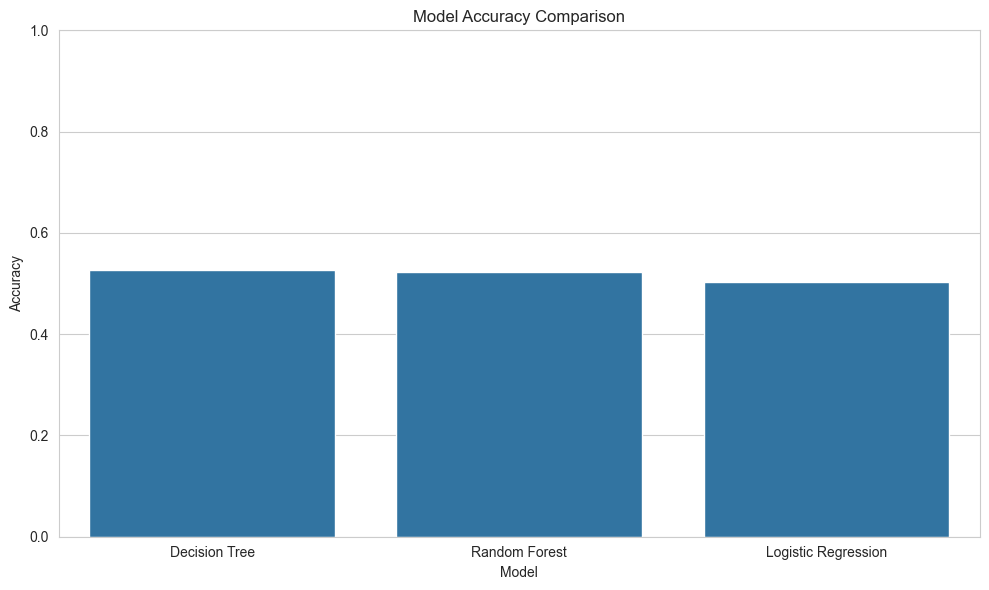

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

#### Confusion matrix (Random Forest)

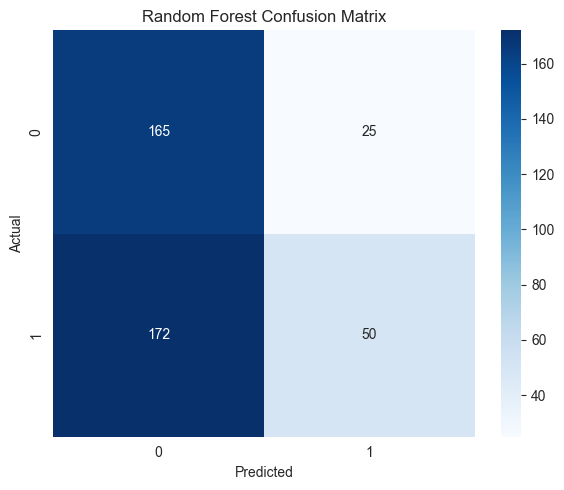

In [56]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

#### Classification report

In [57]:
print(
    classification_report(
        y_test,
        rf_preds
    )
)

              precision    recall  f1-score   support

           0       0.49      0.87      0.63       190
           1       0.67      0.23      0.34       222

    accuracy                           0.52       412
   macro avg       0.58      0.55      0.48       412
weighted avg       0.59      0.52      0.47       412



#### ROC Curve

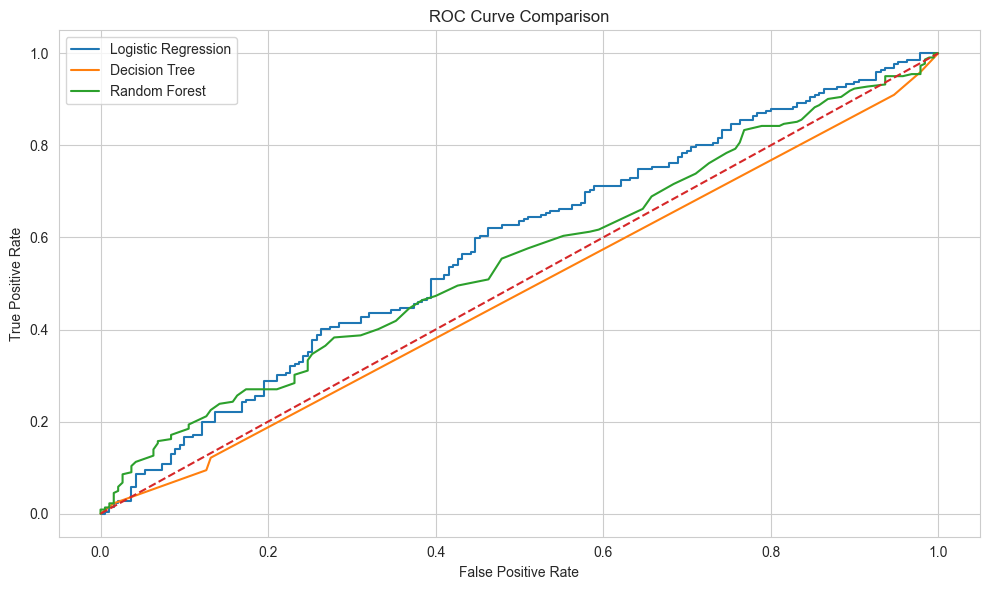

In [58]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(10, 6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_tree, tpr_tree, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()
plt.show()

#### Feature importance

In [59]:
importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
13,AMD_Return_Lag1,0.054014
20,MSFT_Return,0.053647
11,NVDA_Volume_Lag1,0.052467
22,^IXIC_Return,0.050488
1,NVDA_Volume,0.049909
10,NVDA_Return_Lag1,0.049184
5,NVDA_Volatility20,0.048762
21,AMD_Return,0.048200
2,NVDA_Return,0.047889
16,NVDA_Volume_Roll5,0.047707


#### Feature importance visualization

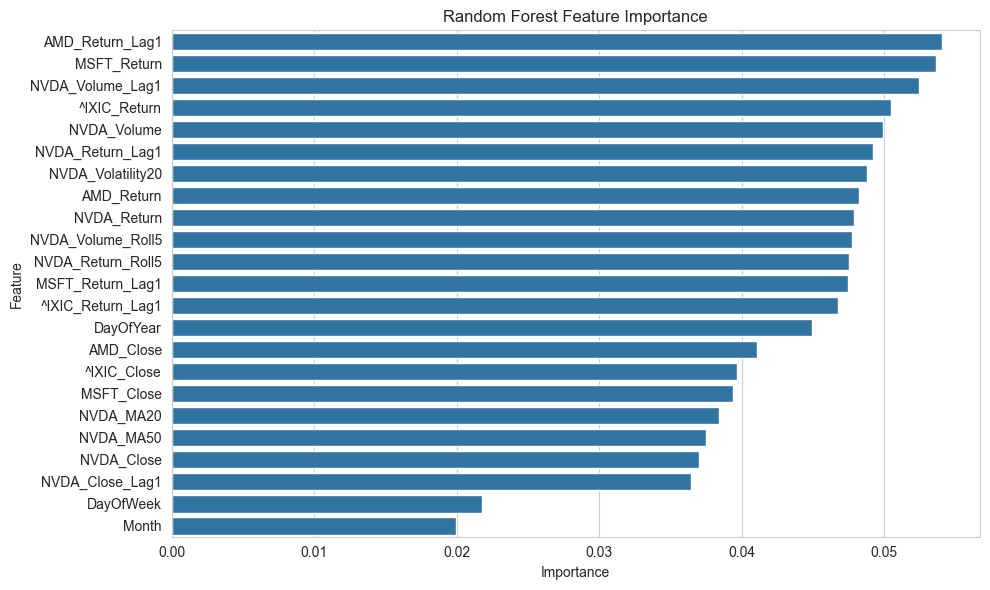

In [60]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

#### Save results

In [61]:
results_df.to_csv(
    "../reports/predictive_modeling/model_comparison_results.csv",
    index=False
)

importance_df.to_csv(
    "../reports/predictive_modeling/feature_importance.csv",
    index=False
)

print("Results saved successfully")

Results saved successfully
